                            OLS Regression Results                            
Dep. Variable:                   발생두수   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     6.599
Date:                Wed, 25 Jun 2025   Prob (F-statistic):           0.000199
Time:                        14:21:41   Log-Likelihood:                -7160.4
No. Observations:                1368   AIC:                         1.433e+04
Df Residuals:                    1364   BIC:                         1.435e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -78.9098     54

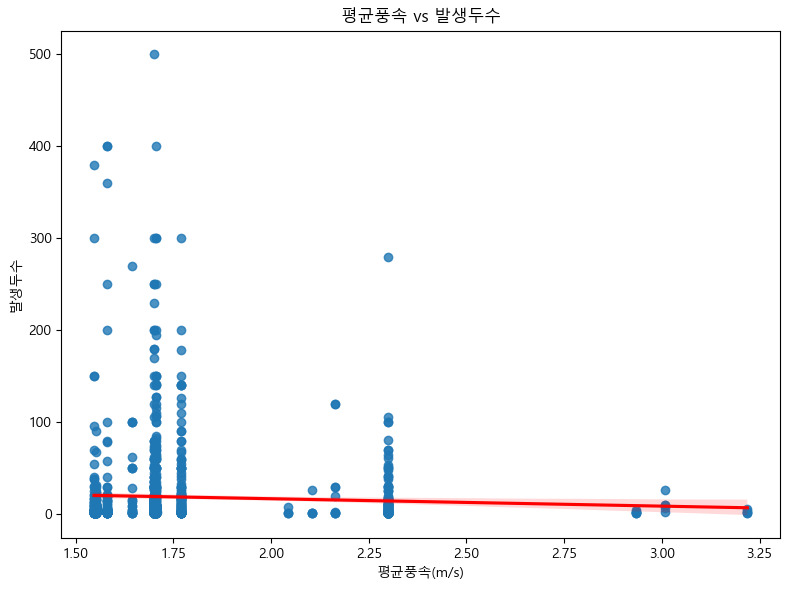

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from shapely.geometry import Point
import matplotlib.font_manager as fm
import matplotlib as mpl

# 한글 폰트 설정
font_path = 'C:/Windows/Fonts/malgun.ttf'
fontprop = fm.FontProperties(fname=font_path)
mpl.rc('font', family=fontprop.get_name())
mpl.rcParams['axes.unicode_minus'] = False

weather = pd.read_csv("../../data/raw/weather.csv", encoding='euc-kr')
weather_station = pd.read_csv("../../data/raw/weather_station_info.csv", encoding='euc-kr')

weather[['year', 'month']] = weather['일시'].str.split('-', expand=True)
weather['year'] = weather['year'].astype(int)
weather['month'] = weather['month'].astype(int)

def get_season(month):
    if month in [6, 7, 8]:
        return 'summer'
    return 'other'

weather['season'] = weather['month'].apply(get_season)

summer_avg = weather[weather['season'] == 'summer'].groupby('지점')[
    ['평균최고기온(°C)', '평균최저기온(°C)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)']
].mean().reset_index()

weather_station = weather_station[['지점', '위도', '경도']]
summer_avg = summer_avg.merge(weather_station, on='지점', how='left')

weather_gdf = gpd.GeoDataFrame(
    summer_avg,
    geometry=gpd.points_from_xy(summer_avg['경도'], summer_avg['위도']),
    crs="EPSG:4326"
)

korea_map = gpd.read_file("../../data/raw/map.shp", encoding='euc-kr')
if korea_map.crs is None:
    korea_map.set_crs("EPSG:5179", inplace=True)
korea_map = korea_map.to_crs("EPSG:4326")
weather_gdf = gpd.sjoin(weather_gdf, korea_map[['CTP_KOR_NM', 'geometry']], how='left', predicate='within')

region_weather = weather_gdf.groupby('CTP_KOR_NM')[
    ['평균최고기온(°C)', '평균최저기온(°C)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)']
].mean().reset_index()

bee = pd.read_csv("../../data/raw/SBV_Infection_Location.csv", encoding='euc-kr')
bee = bee[['Latitude', 'Longitude', '발생두수', '축종']].dropna()

bee_gdf = gpd.GeoDataFrame(
    bee,
    geometry=gpd.points_from_xy(bee['Longitude'], bee['Latitude']),
    crs="EPSG:4326"
)
bee_gdf = gpd.sjoin(bee_gdf, korea_map[['CTP_KOR_NM', 'geometry']], how='left', predicate='within')

df = bee_gdf.merge(region_weather, on='CTP_KOR_NM', how='left').dropna()

X = df[['평균최고기온(°C)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)']]
X = sm.add_constant(X)
y = df['발생두수']

model = sm.OLS(y, X).fit()
print(model.summary())

plt.figure(figsize=(8, 6))
sns.regplot(x='평균풍속(m/s)', y='발생두수', data=df, ci=95, line_kws={"color": "red"})
plt.title("평균풍속 vs 발생두수")
plt.xlabel("평균풍속(m/s)")
plt.ylabel("발생두수")
plt.tight_layout()
plt.savefig("../../outputs/figures/2_1_4_regression_multi_climate_vs_infection.png", dpi=300)
plt.show()


C:\Users\haa\AppData\Local\Temp\ipykernel_41824\802894697.py:62: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = stations.geometry.distance(row.geometry)
C:\Users\haa\AppData\Local\Temp\ipykernel_41824\802894697.py:62: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = stations.geometry.distance(row.geometry)
C:\Users\haa\AppData\Local\Temp\ipykernel_41824\802894697.py:62: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distances = stations.geometry.distance(row.geometry)
C:\Users\haa\AppData\Local\Temp\ipykernel_41824\802894697.py:62: UserWarning: Geometr

                            OLS Regression Results                            
Dep. Variable:                   발생두수   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     11.58
Date:                Wed, 25 Jun 2025   Prob (F-statistic):           1.70e-07
Time:                        14:24:14   Log-Likelihood:                -7153.0
No. Observations:                1368   AIC:                         1.431e+04
Df Residuals:                    1364   BIC:                         1.433e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                123.8000     35

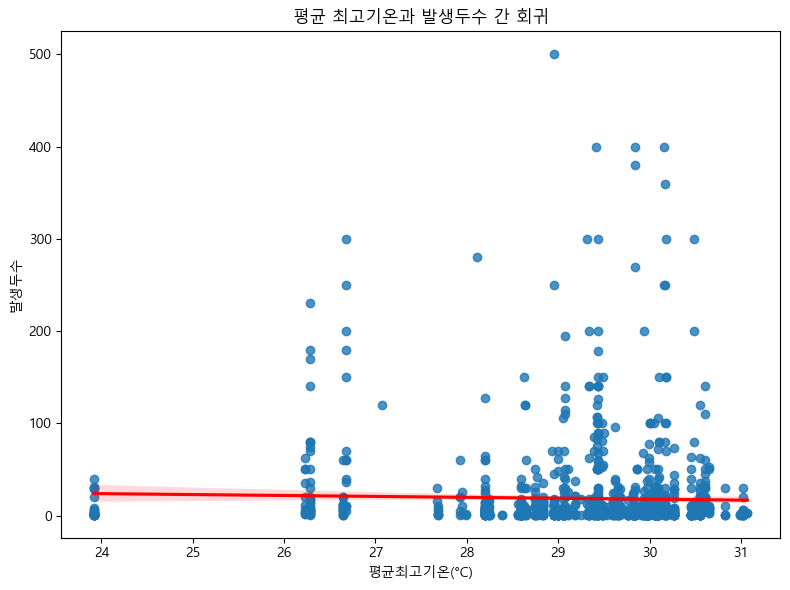

In [ ]:
weather = pd.read_csv("../../data/raw/weather.csv", encoding='euc-kr')
station_info = pd.read_csv("../../data/raw/weather_station_info.csv", encoding='euc-kr')
bee_data = pd.read_csv("../../data/raw/SBV_Infection_Location.csv", encoding='euc-kr')

weather[['year', 'month']] = weather['일시'].str.split('-', expand=True)
weather['year'] = weather['year'].astype(int)
weather['month'] = weather['month'].astype(int)

def season_month(month):
    if month in [6, 7, 8]:
        return 'summer'
    else:
        return 'other'
weather['season'] = weather['month'].apply(season_month)

summer_weather = weather[weather['season'] == 'summer']

weather_features = ['평균최고기온(°C)', '평균최저기온(°C)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)']
summer_avg = summer_weather.groupby('지점')[weather_features].mean().reset_index()

station_info = station_info[['지점', '위도', '경도']]
summer_avg = summer_avg.merge(station_info, on='지점', how='left')

weather_gdf = gpd.GeoDataFrame(
    summer_avg,
    geometry=gpd.points_from_xy(summer_avg['경도'], summer_avg['위도']),
    crs="EPSG:4326"
)

bee_data = bee_data[['Longitude', 'Latitude', '발생두수', '축종']].dropna()
bee_gdf = gpd.GeoDataFrame(
    bee_data,
    geometry=gpd.points_from_xy(bee_data['Longitude'], bee_data['Latitude']),
    crs="EPSG:4326"
)

def find_nearest_station(row, stations):
    distances = stations.geometry.distance(row.geometry)
    nearest_idx = distances.idxmin()
    return stations.loc[nearest_idx, weather_features]

bee_gdf[weather_features] = bee_gdf.apply(find_nearest_station, axis=1, stations=weather_gdf)

df = bee_gdf.dropna(subset=['발생두수'] + weather_features)
X = df[['평균최고기온(°C)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)']]
X = sm.add_constant(X)
y = df['발생두수']
model = sm.OLS(y, X).fit()

print(model.summary())

plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='평균최고기온(°C)', y='발생두수', line_kws={"color": "red"})
plt.title("평균 최고기온과 발생두수 간 회귀")
plt.tight_layout()
plt.savefig("../../outputs/figures/2_1_4_regression_tempstation_vs_infection.png", dpi=300)
plt.show()


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm

weather = pd.read_csv("../../data/raw/weather.csv", encoding='euc-kr')
station_info = pd.read_csv("../../data/raw/weather_station_info.csv", encoding='euc-kr')

weather[['year', 'month']] = weather['일시'].str.split('-', expand=True)
weather['month'] = weather['month'].astype(int)
weather['season'] = weather['month'].apply(lambda m: 'winter' if m in [12, 1, 2] else
                                                       'spring' if m in [3, 4, 5] else
                                                       'summer' if m in [6, 7, 8] else 'fall')

station_info = station_info[['지점', '위도', '경도']]
weather = weather.merge(station_info, on='지점', how='left')

winter_avg = weather[weather['season'] == 'winter'].groupby('지점')[
    ['평균최저기온(°C)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)']
].mean().reset_index()

winter_avg = winter_avg.merge(station_info, on='지점', how='left')
gdf_stations = gpd.GeoDataFrame(
    winter_avg,
    geometry=gpd.points_from_xy(winter_avg['경도'], winter_avg['위도']),
    crs='EPSG:4326'
)

bee = pd.read_csv("../../data/raw/SBV_Infection_Location.csv", encoding='euc-kr')
bee = bee[['Longitude', 'Latitude', '발생두수']].dropna()
bee_gdf = gpd.GeoDataFrame(
    bee,
    geometry=gpd.points_from_xy(bee['Longitude'], bee['Latitude']),
    crs='EPSG:4326'
)

nearest = bee_gdf.sjoin_nearest(gdf_stations, how='left', distance_col='dist')

df = nearest.dropna(subset=['발생두수', '평균최저기온(°C)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)'])
X = sm.add_constant(df[['평균최저기온(°C)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)']])
y = df['발생두수']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   발생두수   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     5.299
Date:                Wed, 25 Jun 2025   Prob (F-statistic):            0.00123
Time:                        14:26:04   Log-Likelihood:                -8130.5
No. Observations:                1564   AIC:                         1.627e+04
Df Residuals:                    1560   BIC:                         1.629e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 34.0881      8

c:\.soyeon\Bee\.bee\Lib\site-packages\geopandas\array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


평균기온 차이

C:\Users\haa\AppData\Local\Temp\ipykernel_41824\1903335455.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda x: station_gdf.distance(x).idxmin()
C:\Users\haa\AppData\Local\Temp\ipykernel_41824\1903335455.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda x: station_gdf.distance(x).idxmin()
C:\Users\haa\AppData\Local\Temp\ipykernel_41824\1903335455.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda x: station_gdf.distance(x).idxmin()
C:\Users\haa\AppData\Local\Temp\ipykernel_41824\1903335455.py:54: UserWarning: Geometry is in a geographic CRS. 

                            OLS Regression Results                            
Dep. Variable:                   발생두수   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     24.31
Date:                Wed, 25 Jun 2025   Prob (F-statistic):           9.19e-07
Time:                        14:29:56   Log-Likelihood:                -7158.2
No. Observations:                1368   AIC:                         1.432e+04
Df Residuals:                    1366   BIC:                         1.433e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         99.1189     16.377      6.052      0.0

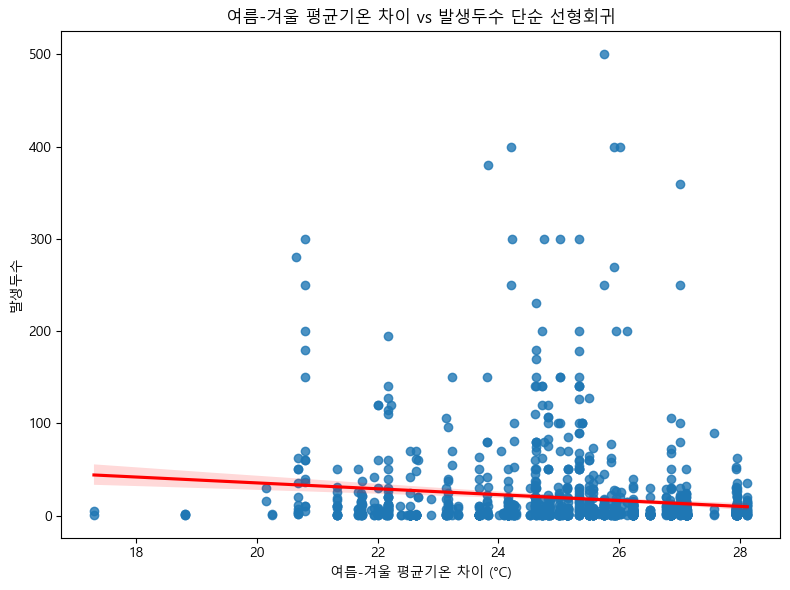

In [ ]:
weather = pd.read_csv("../../data/raw/weather.csv", encoding='euc-kr')
station_info = pd.read_csv("../../data/raw/weather_station_info.csv", encoding='euc-kr')
bee_df = pd.read_csv("../../data/raw/SBV_Infection_Location.csv", encoding='euc-kr')

weather[['year', 'month']] = weather['일시'].str.split('-', expand=True).astype(int)
def get_season(month):
    if month in [6, 7, 8]:
        return 'summer'
    elif month in [12, 1, 2]:
        return 'winter'
    else:
        return None
weather['season'] = weather['month'].apply(get_season)

weather = weather.merge(station_info[['지점', '위도', '경도']], on='지점', how='left')
seasonal_temp = weather[weather['season'].notnull()]
avg_temp = seasonal_temp.groupby(['지점', 'season'])['평균기온(°C)'].mean().unstack().dropna()
avg_temp['temp_diff'] = avg_temp['summer'] - avg_temp['winter']
avg_temp = avg_temp.reset_index().merge(station_info[['지점', '위도', '경도']], on='지점', how='left')

bee_df = bee_df[['Longitude', 'Latitude', '발생두수']].dropna()
bee_gdf = gpd.GeoDataFrame(
    bee_df,
    geometry=gpd.points_from_xy(bee_df['Longitude'], bee_df['Latitude']),
    crs="EPSG:4326"
)
station_gdf = gpd.GeoDataFrame(
    avg_temp,
    geometry=gpd.points_from_xy(avg_temp['경도'], avg_temp['위도']),
    crs="EPSG:4326"
)

bee_gdf['nearest_station'] = bee_gdf.geometry.apply(
    lambda x: station_gdf.distance(x).idxmin()
)
bee_gdf['temp_diff'] = bee_gdf['nearest_station'].map(station_gdf['temp_diff'])

df = bee_gdf.dropna(subset=['temp_diff', '발생두수'])
X = sm.add_constant(df['temp_diff'])
y = df['발생두수']
model = sm.OLS(y, X).fit()
print(model.summary())

plt.figure(figsize=(8, 6))
sns.regplot(x='temp_diff', y='발생두수', data=df, ci=95, line_kws={"color": "red"})
plt.title("여름-겨울 평균기온 차이 vs 발생두수 단순 선형회귀")
plt.xlabel("여름-겨울 평균기온 차이 (°C)")
plt.ylabel("발생두수")
plt.tight_layout()
plt.savefig("../../outputs/figures/2_1_4_temp_diff_vs_infection.png", dpi=300)
plt.show()
